In [1]:
import os

# Subir un nivel respecto a la carpeta actual
os.chdir("..")

import numpy as np
from globals import SAMPLE_RATE
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from Utils import from_matrix_to_preset, denormalize_preset, pretty_print, get_audio, split_audio
import numpy as np
import matplotlib.pyplot as plt
from Optimizers import search_with_DE, search_with_CMA, evaluate_target, render_presets

c:\Users\bryan\Documents\GitHub\Synth\Utils.py:505: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _sr = librosa.load(audio_path, sr=SAMPLE_RATE)
c:\Users\bryan\Documents\GitHub\Synth\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


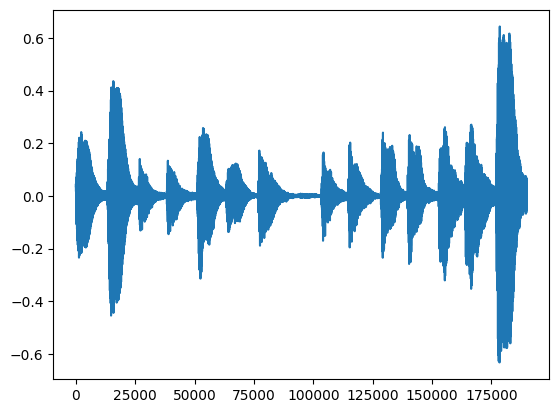

In [2]:
audio_path = 'C:/Users/bryan/Documents/GitHub/Synth/presets/TwinkleFast.m4a'
audio = get_audio(audio_path)

plt.plot(audio)
plt.show()
Audio(audio, rate=SAMPLE_RATE)

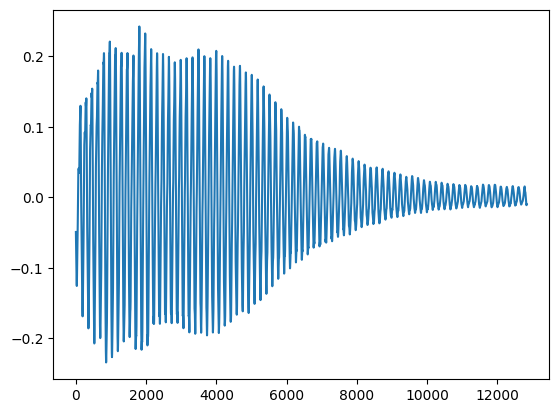

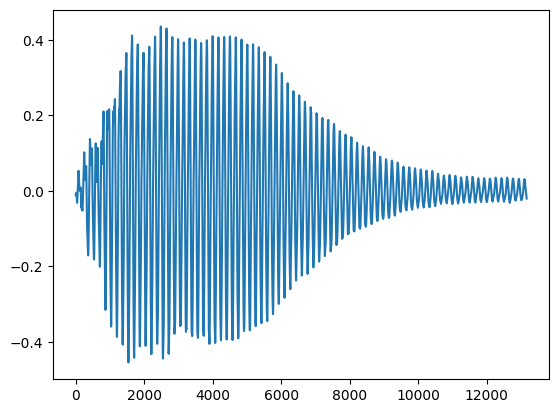

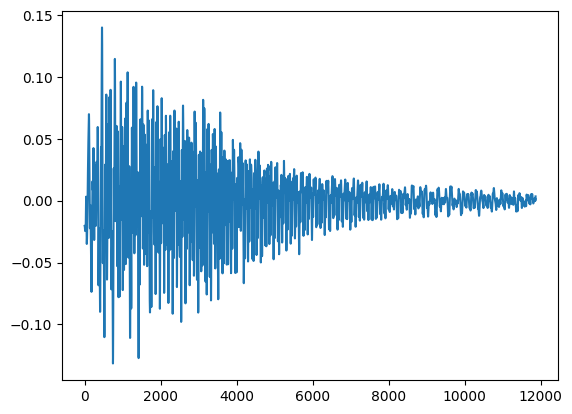

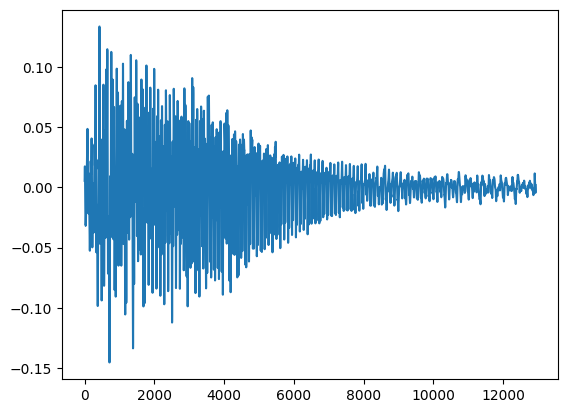

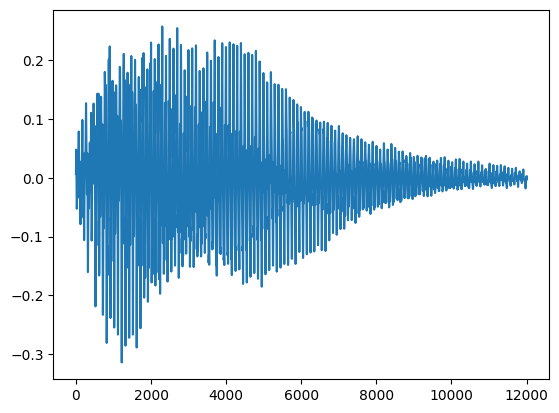

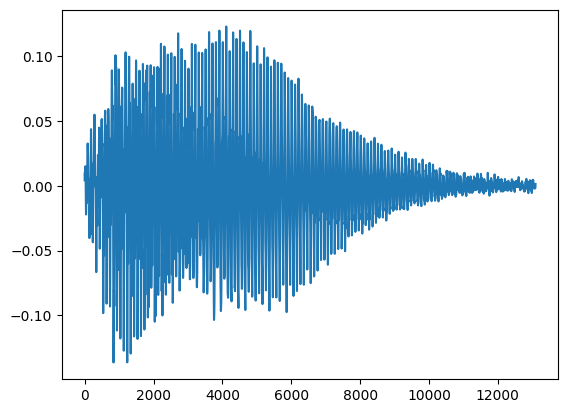

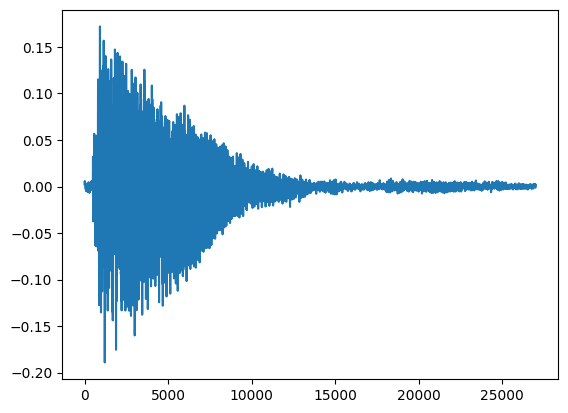

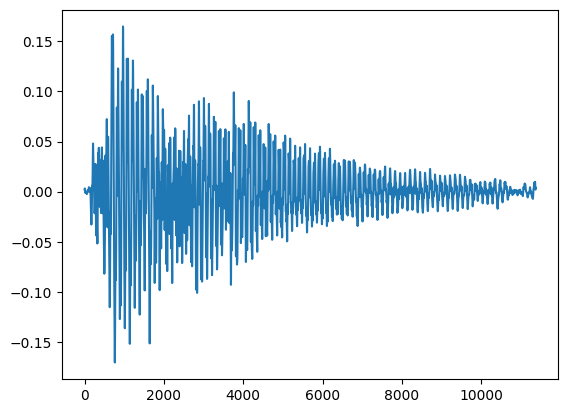

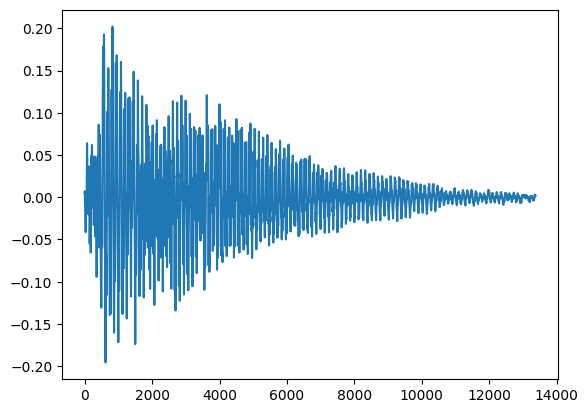

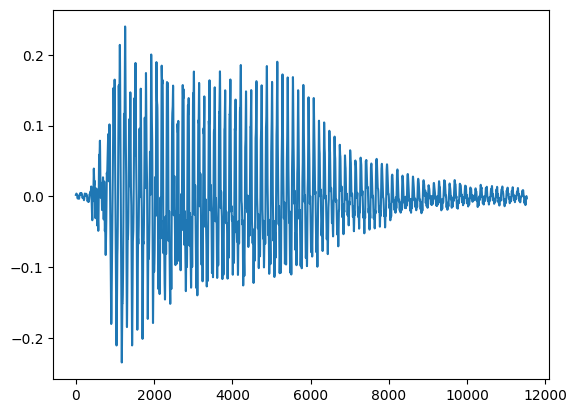

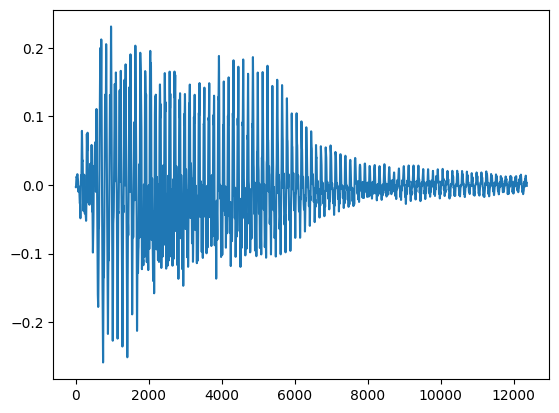

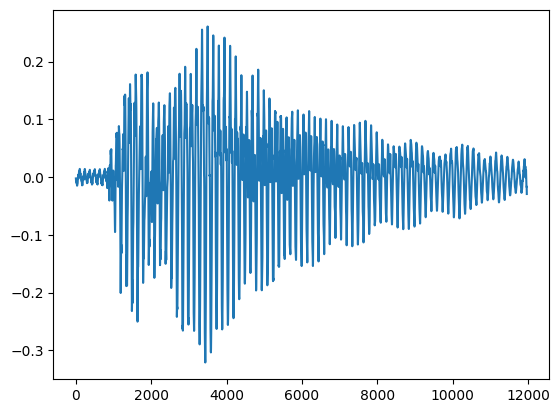

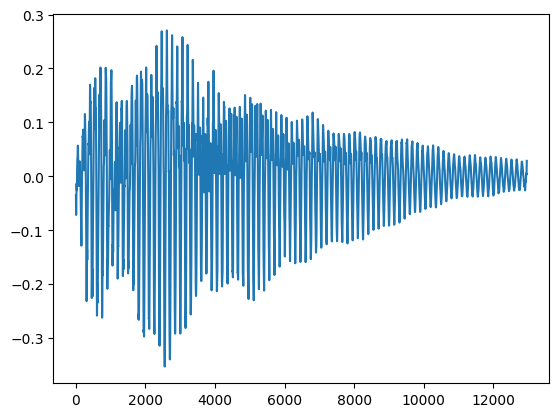

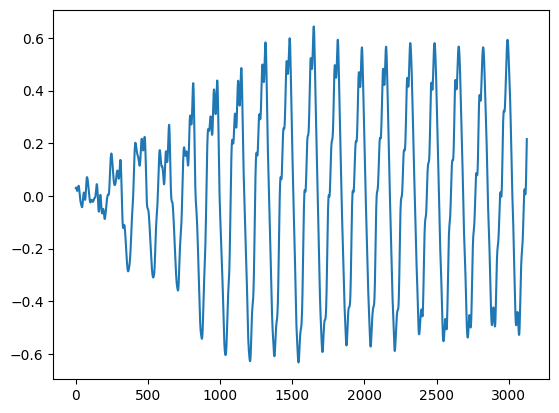

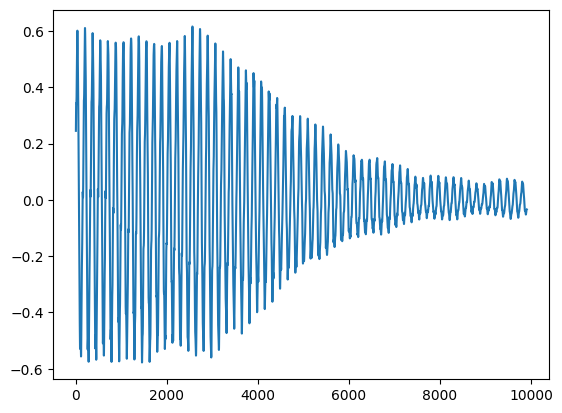

Pieces 15


In [3]:
audio_segments = split_audio(audio, prominence=0.025)

for audio_segment in audio_segments:
    plt.plot(audio_segment)
    plt.show()
    display(Audio(audio_segment, rate=SAMPLE_RATE))

print('Pieces', len(audio_segments))

In [4]:
estimated_presets = []
i = 1
last_best = None

if __name__ == '__main__':
    for audio_segment in audio_segments:
        print('Piece', i)
        target_C = evaluate_target(np.expand_dims(audio_segment, axis=0))
        duration = len(audio_segment) / SAMPLE_RATE
        if last_best is None:
            best = search_with_DE(target_C, duration, disp=False, maxiter=200)
            best = search_with_CMA(target_C, duration, best)
        else:
            best = search_with_CMA(target_C, duration, last_best)

        last_best = best
        estimated_presets.append((best, duration))
        i+=1

Piece 1


c:\Users\bryan\Documents\GitHub\Synth\venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:487: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=323163, Wed Feb  4 18:58:12 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=358416, Wed Feb  4 18:58:57 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=336874, Wed Feb  4 18:59:42 2026)
Piece 2
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=371607, Wed Feb  4 19:00:29 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=337748, Wed Feb  4 19:01:17 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=383333, Wed Feb  4 19:01:52 2026)
Piece 3
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=295957, Wed Feb  4 19:02:51 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=312306, Wed Feb  4 19:03:59 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=335218, Wed Feb  4 19:05:54 2026)
Piece 4
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=362726, Wed Feb  4 19:06:27 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimens

In [5]:
predicted_joined_audio = []

for preset, duration in estimated_presets:
    preset = np.expand_dims(preset, axis=0)
    # error = evaluate_presets((denormalize_preset(from_matrix_to_preset(preset)), target_C, duration))
    # print('Error', error)
    # target_audio = np.expand_dims(audio_segments[0], axis=0)
    predicted_audio = render_presets(denormalize_preset(from_matrix_to_preset(preset)), duration)
    predicted_joined_audio.append(predicted_audio[0])

    denormalized_predicted_preset = denormalize_preset(from_matrix_to_preset(preset))
    pretty_print(denormalized_predicted_preset)

predicted_joined_audio = np.concatenate(predicted_joined_audio, axis=0)

{
  osc1_shape:   [
    2.6017620395081895
  ]
  osc1_phase:   [
    0.07587970550046635
  ]
  osc1_volume:   [
    0.37729203211863527
  ]
  osc1_freq:   [
    267.7192891782101
  ]
  osc2_shape:   [
    3.999955348689936
  ]
  osc2_phase:   [
    0.26495839590583836
  ]
  osc2_volume:   [
    0.20789881932065235
  ]
  osc2_freq:   [
    3729.0439736541075
  ]
  osc3_shape:   [
    2.0761860641139798
  ]
  osc3_phase:   [
    0.2047105824718765
  ]
  osc3_volume:   [
    0.8756820815057507
  ]
  osc3_freq:   [
    264.75828388952937
  ]
  osc4_shape:   [
    3.831472937668575
  ]
  osc4_phase:   [
    0.5048385918793612
  ]
  osc4_volume:   [
    0.3499476461080755
  ]
  osc4_freq:   [
    258.78588419000846
  ]
  oscnoise_volume:   [
    0.46529987571968906
  ]
  filter_envelope_attack:   [
    0.2692330951986055
  ]
  filter_envelope_decay:   [
    0.8841364601151456
  ]
  filter_envelope_sustain:   [
    0.04297823212263585
  ]
  filter_envelope_release:   [
    0.30038033417925086

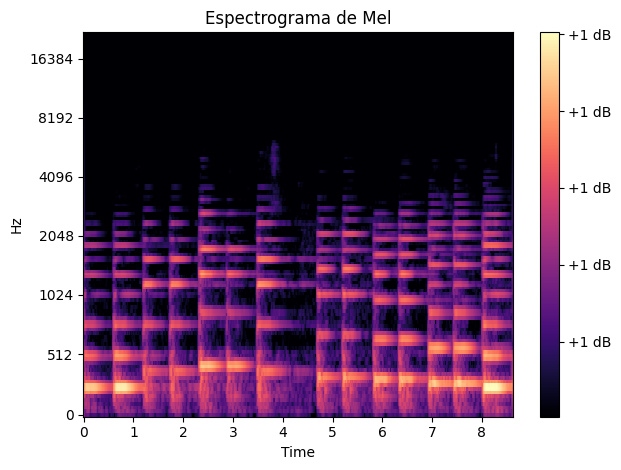

In [6]:
spect = evaluate_target(np.array([audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(audio, rate=SAMPLE_RATE))

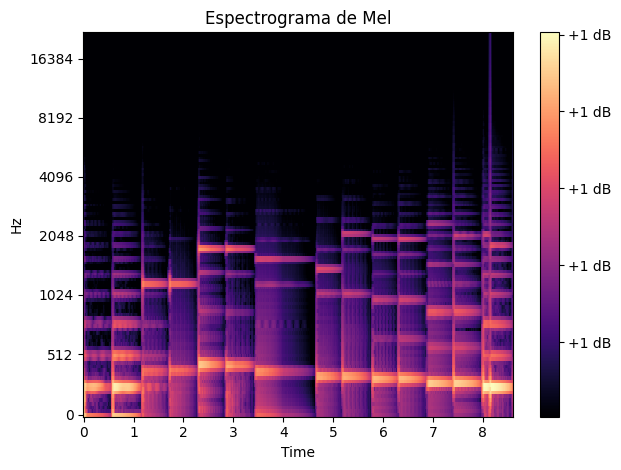

In [7]:
spect = evaluate_target(np.array([predicted_joined_audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(predicted_joined_audio, rate=SAMPLE_RATE))